In [11]:
!pip install tensorflow

In [12]:
!pip install tensorflow_hub

In [13]:
import os
os.environ["TFHUB_OFFLINE"] = "1"
os.environ['TFHUB_CACHE_DIR'] = './tfhub_modules' # Point to your cache
os.environ['TFHUB_DOWNLOAD_PROGRESS'] = '1'       # See if it's actually downloading
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

In [14]:
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import scipy
from PIL import Image
from matplotlib.pyplot import imshow


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Anaconda\envs\densehybrid\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Anaconda\envs\densehybrid\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Anaconda\envs\densehybrid\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Anaconda\envs\densehybrid\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Anaconda\envs\dens

AttributeError: _ARRAY_API not found

c:\Anaconda\envs\densehybrid\lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [2]:
#metric for measuring quality performance (ignore for testing on a single image)
def srcc(y_true, y_pred):
     return ( tf.py_function(spearmanr, [tf.cast(y_pred, tf.float32),
                       tf.cast(y_true, tf.float32)], Tout = tf.float32) )

In [3]:
IMG_SIZE = 448
CHANNELS = 3 

In [16]:
# #preprocessing for input
# def test_img(filename, model):
#     image_string = tf.io.read_file(filename)
#     image_decoded = tf.image.decode_jpeg(image_string, channels=CHANNELS)
#     image_resized = tf.image.resize(image_decoded, [IMG_SIZE, IMG_SIZE])
#     image_normalized = image_resized / 255.0
#     pred = model.predict(np.array([image_normalized,]))
#     return pred

# Preprocessing for input for roipool
def test_img(filename, model):
    image_string = tf.io.read_file(filename)
    image_decoded = tf.image.decode_jpeg(image_string, channels=CHANNELS)
    image_resized = tf.image.resize(image_decoded, [IMG_SIZE, IMG_SIZE])
    image_normalized = image_resized / 255.0
    
    # Create dummy ROI that covers the entire image
    # ROI format: [x, y, width, height]
    # For full image coverage on 448x448 image
    roi = np.array([[0, 0, IMG_SIZE, IMG_SIZE]], dtype=np.float32)
    
    pred = model.predict({
        'input_layer': np.array([image_normalized]),
        'input_rois': roi
    })
    return pred

In [4]:
IMG_SIZE = 448
CHANNELS = 3 

In [6]:
# For resnet50
def build_model():
    IMG_SIZE = 448
    CHANNELS = 3

    # Base feature extractor (same as training)
    base_model = tf.keras.applications.ResNet50V2(
        input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    # Input
    input_layer = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS))

    # Backbone
    x = base_model(input_layer, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(512, activation='relu', name='hidden_layer1')(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    # Head 1 → Quality score (output_2)
    x1 = tf.keras.layers.Dense(32, activation='relu', name='hidden_layer2')(x)
    x1 = tf.keras.layers.Dropout(0.2)(x1)
    output_2 = tf.keras.layers.Dense(1, name='output_2')(x1)

    # Head 2 → Distortion distribution (output_1)
    x2 = tf.keras.layers.Dense(32, activation='relu', name='hidden_layer3')(x)
    x2 = tf.keras.layers.Dropout(0.2)(x2)
    output_1 = tf.keras.layers.Dense(7, name='output_1')(x2)

    model = tf.keras.models.Model(inputs=input_layer,
                                  outputs=[output_1, output_2])

    return model

# For roipool
# from tensorflow.keras.layers import Layer
# from tensorflow.keras import backend as K

# class RoiPoolingConv(Layer):
#     def __init__(self, pool_size, num_rois, **kwargs):
#         self.pool_size = pool_size
#         self.num_rois = num_rois
#         super(RoiPoolingConv, self).__init__(**kwargs)

#     def build(self, input_shape):
#         self.nb_channels = input_shape[0][3]

#     def compute_output_shape(self, input_shape):
#         return None, self.num_rois, self.pool_size, self.pool_size, self.nb_channels

#     def call(self, x, mask=None):
#         assert(len(x) == 2)
        
#         img = x[0]
#         rois = x[1]
        
#         x = rois[0, 0]
#         y = rois[0, 1]
#         w = rois[0, 2]
#         h = rois[0, 3]
        
#         x = K.cast(x, 'int32')
#         y = K.cast(y, 'int32')
#         w = K.cast(w, 'int32')
#         h = K.cast(h, 'int32')
        
#         rs = tf.image.resize(img[:, y:y+h, x:x+w, :], (self.pool_size, self.pool_size))
        
#         batch_size = K.shape(img)[0]
#         final_output = K.reshape(rs, (batch_size, self.num_rois, self.pool_size, self.pool_size, self.nb_channels))
#         return final_output

#     def get_config(self):
#         config = {'pool_size': self.pool_size,
#                   'num_rois': self.num_rois}
#         base_config = super(RoiPoolingConv, self).get_config()
#         return dict(list(base_config.items()) + list(config.items()))

# def build_model():
#     IMG_SIZE = 448
#     CHANNELS = 3
    
#     # Base feature extractor
#     base_model = tf.keras.applications.ResNet50V2(
#         input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS),
#         include_top=False,
#         weights='imagenet'
#     )
#     base_model.trainable = False
    
#     # Inputs
#     input_rois = tf.keras.layers.Input(shape=(4,), name='input_rois')
#     input_layer = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS), name='input_layer')
    
#     # Base model extracts features
#     base_layers = base_model(input_layer, training=False)
    
#     # ROI pooling to extract 2x2 region
#     out_roi_pool = RoiPoolingConv(2, 1)([base_layers, input_rois])
    
#     # Flatten and pass through dense layers
#     x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten(name='flatten'))(out_roi_pool)
#     x = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(512, activation='relu', name='fc1'))(x)
#     x = tf.keras.layers.TimeDistributed(tf.keras.layers.Dropout(0.2))(x)
    
#     # Head 1 → Quality score (output_1)
#     x1 = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(32, activation='relu', name='hidden_layer2'))(x)
#     x1 = tf.keras.layers.TimeDistributed(tf.keras.layers.Dropout(0.2))(x1)
#     output_1 = tf.keras.layers.Dense(1, name='output_1')(x1)
    
#     # Head 2 → Distortion distribution (output_2)
#     x2 = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(32, activation='relu', name='hidden_layer3'))(x)
#     x2 = tf.keras.layers.TimeDistributed(tf.keras.layers.Dropout(0.2))(x2)
#     output_2 = tf.keras.layers.Dense(7, name='output_2')(x2)
    
#     model = tf.keras.models.Model(inputs=[input_layer, input_rois], 
#                                   outputs=[output_1, output_2])
    
#     return model

In [8]:
# For mobilenet
def build_model_mobilenet():
    IMG_SIZE = 448
    CHANNELS = 3

    # Base feature extractor (MobileNetV2)
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    # Input
    input_layer = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS))

    # Backbone
    x = base_model(input_layer, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(512, activation='relu', name='hidden_layer1')(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    # Head 1 → Quality score (output_2)
    x1 = tf.keras.layers.Dense(32, activation='relu', name='hidden_layer2')(x)
    x1 = tf.keras.layers.Dropout(0.2)(x1)
    output_2 = tf.keras.layers.Dense(1, name='output_2')(x1)

    # Head 2 → Distortion distribution (output_1)
    x2 = tf.keras.layers.Dense(32, activation='relu', name='hidden_layer3')(x)
    x2 = tf.keras.layers.Dropout(0.2)(x2)
    output_1 = tf.keras.layers.Dense(7, name='output_1')(x2)

    model = tf.keras.models.Model(inputs=input_layer,
                                  outputs=[output_1, output_2])

    return model

In [17]:
#change the path to the test model
# This ignores the 'srcc' metric entirely during loading, which is much faster
# test_model = tf.keras.models.load_model(
#     'test_models/resnet50.h5', 
#     custom_objects={'KerasLayer': hub.KerasLayer},
#     compile=False
# )
# test_model = tf.keras.models.load_model('test_models/resnet50.h5', custom_objects={'KerasLayer':hub.KerasLayer,'srcc':srcc})

# roipool
# test_model = build_model()
# test_model.load_weights('test_models/resnet50_roipool.h5')

# For ResNet50 (use test_img_simple)
# test_model = build_model()
# test_model.load_weights('test_models/resnet50.h5')
# test_preprocessing = test_img_simple

# For MobileNet (use test_img_simple)
test_model = build_model_mobilenet()
test_model.load_weights('test_models/mobilenet.h5')
test_preprocessing = test_img

C:\Users\YASHVI KHATRI\AppData\Local\Temp\ipykernel_17956\1341181866.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [1]:
# def feedback(img, model, test_img):
#     im = Image.open(img)
#     imshow(np.asarray(im))
#     pred = test_img(img, model)
#     # roipool
#     qual = float(pred[0][0][0]) 
#     dist = pred[1][0][0]

#     # resnet50
#     # qual = pred[1].item() 
#     # dist = pred[0][0]
#     print('Predicted global quality: ', qual)
#     D = ['Blurry','Shaky','Bright','Dark','Grainy','None','Other']
#     idx = np.argmax(dist)
#     print('Most prominent distortion: ',D[idx])
#     idx3 = dist.argsort()[-3:][::-1]
#     print('Max 3 prominent distortions are: ', [D[i] for i in idx3])        
#     print('All distortions: ')
#     for i in range(7):
#         print(D[i],': ',dist[i])

# Mobilenet
def feedback(img, model, test_preprocessing):
    im = Image.open(img)
    imshow(np.asarray(im))
    pred = test_preprocessing(img, model)
    
    # For simple models (MobileNet, ResNet50)
    qual = float(pred[1][0][0])  # Quality score from output_2
    dist = pred[0][0]  # Distortion distribution from output_1
    
    print('Predicted global quality: ', qual)
    D = ['Blurry','Shaky','Bright','Dark','Grainy','None','Other']
    idx = np.argmax(dist)
    print('Most prominent distortion: ',D[idx])
    idx3 = dist.argsort()[-3:][::-1]
    print('Max 3 prominent distortions are: ', [D[i] for i in idx3])        
    print('All distortions: ')
    for i in range(7):
        print(D[i],': ',dist[i])

ValueError: Missing data for input "input_layer_3". You passed a data dictionary with keys ['input_layer', 'input_rois']. Expected the following keys: ['input_layer_3']

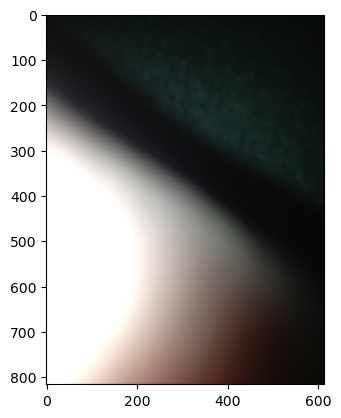

In [18]:
#change the path to test image
# feedback('../Dataset/Vizwiz-Data/test/VizWiz_test_00000001.jpg', test_model, test_img)

# for Mobilenet
feedback('../Dataset/Vizwiz-Data/test/VizWiz_test_00000001.jpg', test_model, test_preprocessing)